In [5]:
import pandas as pd

path = "/Users/tom/Uni_local/master_local/analysis/data/AMF_095_002__C640_C470/derived/comparison_summary.parquet"
beads_vector_correlation_tensor = pd.read_parquet(path)

beads_vector_correlation_tensor

,dataset_id,derived_dir,n_speed,speed_mean,speed_median,speed_std,n_xi3d,xi3d_mean,xi3d_median,n_pc1,pc1_mean,pc1_std
0,AMF_095_002__C640_C470,data/AMF_095_002__C640_C470/derived,52173,0.258904,0.248759,0.150284,0,NaN,NaN,0,NaN,NaN


Shape: (3996, 10)

Columns: ['dataset_id', 'frame', 'time_s', 'channel', 'r_um', 'corr', 'xi_um', 'xi_err_um', 'amp', 'offset']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dataset_id  3996 non-null   str    
 1   frame       3996 non-null   int64  
 2   time_s      3996 non-null   float64
 3   channel     3996 non-null   int64  
 4   r_um        3996 non-null   float64
 5   corr        3996 non-null   float64
 6   xi_um       3996 non-null   float64
 7   xi_err_um   3996 non-null   float64
 8   amp         3996 non-null   float64
 9   offset      3996 non-null   float64
dtypes: float64(7), int64(2), str(1)
memory usage: 398.2 KB
None

Head:


,dataset_id,frame,time_s,channel,r_um,corr,xi_um,xi_err_um,amp,offset
0,AMF_105_002__C640_C470,0,0.0,0,0.00,1.000000,215.346408,11.453266,0.066914,-0.020823
1,AMF_105_002__C640_C470,0,0.0,0,0.39,0.096596,215.346408,11.453266,0.066914,-0.020823
2,AMF_105_002__C640_C470,0,0.0,0,0.65,0.089065,215.346408,11.453266,0.066914,-0.020823
3,AMF_105_002__C640_C470,0,0.0,0,0.91,0.081247,215.346408,11.453266,0.066914,-0.020823
4,AMF_105_002__C640_C470,0,0.0,0,1.17,0.074845,215.346408,11.453266,0.066914,-0.020823



NaNs per key column:
r_um    0
corr    0
dtype: int64

Fit results (A, xi, C):
unweighted                     A=0.091587, xi=434.04 µm, C=-0.049564
weighted_near0                 A=0.066913, xi=215.34 µm, C=-0.020822
near0_only                     A=0.028747, xi=48.516 µm, C=0.019582
robust_softl1_near0_weighted   A=0.082597, xi=372.17 µm, C=-0.040692


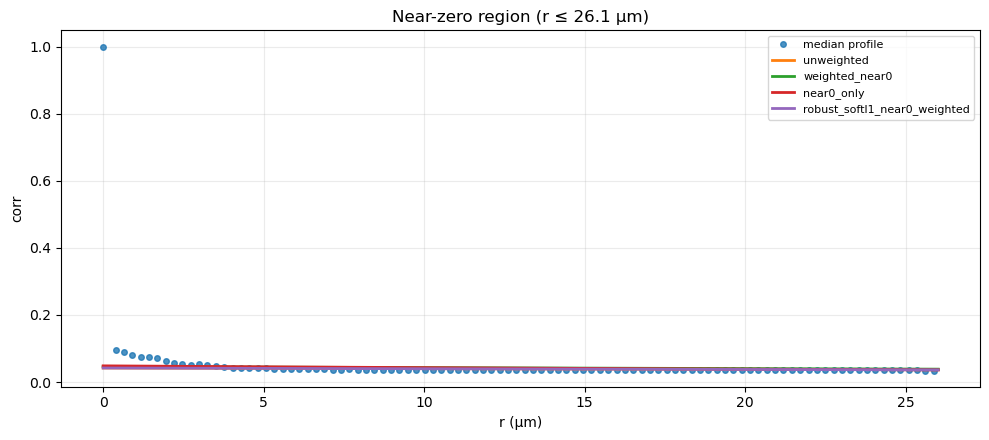

In [25]:
import numpy as np
from scipy.optimize import curve_fit, least_squares

# Load sampled 3D autocorr and inspect it
path_3d = "/Users/tom/Uni_local/master_local/analysis/data/AMF_105_002__C640_C470/derived/autocorr_3d_sampled.parquet"
ac3d = pd.read_parquet(path_3d)

print("Shape:", ac3d.shape)
print("\nColumns:", ac3d.columns.tolist())
print("\nInfo:")
print(ac3d.info())
print("\nHead:")
display(ac3d.head())

# Basic quality checks
print("\nNaNs per key column:")
print(ac3d[["r_um", "corr"]].isna().sum())

# Collapse sampled frames to one radial profile (median is robust)
profile = (
    ac3d.loc[ac3d["frame"] == 0]
    .dropna(subset=["r_um", "corr"])
    .groupby("r_um", as_index=False)
    .agg(corr_median=("corr", "median"), corr_mean=("corr", "mean"), n=("corr", "size"))
    .sort_values("r_um")
)

# Keep r>0 for fitting (zero-lag is usually special)
fit_df = profile[profile["r_um"] > 0].copy()
r = fit_df["r_um"].to_numpy(float)
y = fit_df["corr_median"].to_numpy(float)

import matplotlib.pyplot as plt

def exp_decay(r, A, xi, C):
    return A * np.exp(-r / xi) + C

# Initial guesses
A0 = max(1e-3, float(np.nanmax(y) - np.nanmin(y)))
xi0 = max(0.1, float(np.nanmax(r)) / 8.0)
C0 = float(np.nanmin(y))
p0 = [A0, xi0, C0]
bounds = ([0.0, 0.01, -np.inf], [np.inf, np.inf, np.inf])

fits = {}

# 1) Standard unweighted fit
try:
    p_unw, _ = curve_fit(exp_decay, r, y, p0=p0, bounds=bounds, maxfev=30000)
    fits["unweighted"] = p_unw
except Exception as e:
    print("Unweighted fit failed:", e)

# 2) Weighted fit: emphasize near r=0
# lower sigma => higher weight; near 0 gets smaller sigma
alpha = 2.5 / max(np.nanmax(r), 1e-6)
sigma_near0 = 0.2 + alpha * r
try:
    p_w, _ = curve_fit(exp_decay, r, y, p0=p0, bounds=bounds, sigma=sigma_near0, absolute_sigma=False, maxfev=30000)
    fits["weighted_near0"] = p_w
except Exception as e:
    print("Weighted near-0 fit failed:", e)

# 3) Fit only near-0 region (e.g. first 25% of radius range)
r_cut = np.quantile(r, 0.25)
m_near = r <= r_cut
if m_near.sum() >= 5:
    try:
        p_near, _ = curve_fit(exp_decay, r[m_near], y[m_near], p0=p0, bounds=bounds, maxfev=30000)
        fits["near0_only"] = p_near
    except Exception as e:
        print("Near-0 only fit failed:", e)

# 4) Robust fit (soft_l1), still weighted near 0
def residuals(p, rr, yy, w):
    A, xi, C = p
    return w * (exp_decay(rr, A, xi, C) - yy)

w = 1.0 / sigma_near0
res = least_squares(
    residuals, x0=np.array(p0, float), bounds=np.array(bounds, float),
    args=(r, y, w), loss="soft_l1", f_scale=0.05, max_nfev=50000
)
if res.success:
    fits["robust_softl1_near0_weighted"] = res.x
else:
    print("Robust fit did not converge:", res.message)

# Print fit parameters
print("\nFit results (A, xi, C):")
for name, p in fits.items():
    print(f"{name:30s} A={p[0]:.5g}, xi={p[1]:.5g} µm, C={p[2]:.5g}")

# Plot full range + zoom near zero
r_grid = np.linspace(0, float(np.nanmax(profile["r_um"])), 600)

fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
axes = np.array([None, ax], dtype=object)

# Near-zero zoom
zoom_max = max(0.5, float(np.quantile(profile["r_um"], 0.05)))
mz = profile["r_um"] <= zoom_max
axes[1].plot(profile.loc[mz, "r_um"], profile.loc[mz, "corr_median"], "o", ms=4, alpha=0.8, label="median profile")
for name, p in fits.items():
    axes[1].plot(r_grid[r_grid <= zoom_max], exp_decay(r_grid[r_grid <= zoom_max], *p), lw=2, label=name)
axes[1].set_title(f"Near-zero region (r ≤ {zoom_max:.3g} µm)")
axes[1].set_xlabel("r (µm)")
axes[1].set_ylabel("corr")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
import importlib
from pathlib import Path

import synthetic_motion_experiments

synthetic_motion_experiments = importlib.reload(synthetic_motion_experiments)
outputs = synthetic_motion_experiments.run_synthetic_suite(
    frame_count=60,
    average_window_frames=20,
    particle_count=100,
    seed=7,
    save_animation=True,
    modes=("brownian", "contractile", "extensile"),
)

brownian_result = outputs["brownian"]["result"]
contractile_result = outputs["contractile"]["result"]
extensile_result = outputs["extensile"]["result"]

brownian_animation_path = outputs["brownian"]["animation_path"]
contractile_animation_path = outputs["contractile"]["animation_path"]
extensile_animation_path = outputs["extensile"]["animation_path"]

result = brownian_result
raw_tracks_df = brownian_result["raw_tracks_df"]
tracks_df = brownian_result["tracks_df"]
velocity_df = brownian_result["velocity_df"]
vector_corr_result = brownian_result["result"]
state = brownian_result["state"]

derived_dir = Path(state["paths"]["derived_dir"])
plots_dir = Path(state["paths"]["plots_dir"])

print("Brownian derived dir:", derived_dir)
print("Brownian plots dir:", plots_dir)
print("Brownian raw tracks rows:", len(raw_tracks_df))
print("Brownian averaged tracks rows:", len(tracks_df))
print("Brownian temporal rows:", len(vector_corr_result["temporal_vector_corr_df"]))
print("Brownian spatial rows:", len(vector_corr_result["spatial_vector_corr_df"]))
print("Brownian tensor rows:", len(vector_corr_result["tensor_vector_corr_df"]))
print("Brownian spherical tensor rows:", len(vector_corr_result["tensor_spherical_vector_corr_df"]))
print("Brownian animation:", brownian_animation_path)
print("Contractile animation:", contractile_animation_path)
print("Extensile animation:", extensile_animation_path)


Saved tracks+velocity to data/synthetic_brownian_vector_corr_60tp_avg20/derived/beads_tracks_with_velocity.parquet | rows=300
Saved temporal vector correlation to data/synthetic_brownian_vector_corr_60tp_avg20/derived/beads_vector_correlation_temporal_drift_corrected.parquet
Using frame 1 for spatial vector correlation
Saved spatial vector correlation to data/synthetic_brownian_vector_corr_60tp_avg20/derived/beads_vector_correlation_spatial_drift_corrected.parquet
Using frame 1 for spatial vector tensor correlation
Saved spatial vector tensor correlation (cartesian) to data/synthetic_brownian_vector_corr_60tp_avg20/derived/beads_vector_correlation_tensor_drift_corrected.parquet
Computing spatial tensor time series from 3 frames
Saved spatial tensor time series correlation (cartesian) to data/synthetic_brownian_vector_corr_60tp_avg20/derived/beads_vector_correlation_tensor_time_series_drift_corrected.parquet
Using frame 1 for spatial vector tensor correlation
Saved spatial vector tensor

python(27184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved brownian animation to plots/synthetic_brownian_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_brownian_vector_corr_60tp_avg20_motion_overlay.mp4
Saved tracks+velocity to data/synthetic_contractile_vector_corr_60tp_avg20/derived/beads_tracks_with_velocity.parquet | rows=300
Saved temporal vector correlation to data/synthetic_contractile_vector_corr_60tp_avg20/derived/beads_vector_correlation_temporal_drift_corrected.parquet
Using frame 1 for spatial vector correlation
Saved spatial vector correlation to data/synthetic_contractile_vector_corr_60tp_avg20/derived/beads_vector_correlation_spatial_drift_corrected.parquet
Using frame 1 for spatial vector tensor correlation
Saved spatial vector tensor correlation (cartesian) to data/synthetic_contractile_vector_corr_60tp_avg20/derived/beads_vector_correlation_tensor_drift_corrected.parquet
Computing spatial tensor time series from 3 frames
Saved spatial tensor time series correlation (cartesian) to data/synthetic_contractil

python(27189) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved contractile animation to plots/synthetic_contractile_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_contractile_vector_corr_60tp_avg20_motion_overlay.mp4
Saved tracks+velocity to data/synthetic_extensile_vector_corr_60tp_avg20/derived/beads_tracks_with_velocity.parquet | rows=300
Saved temporal vector correlation to data/synthetic_extensile_vector_corr_60tp_avg20/derived/beads_vector_correlation_temporal_drift_corrected.parquet
Using frame 1 for spatial vector correlation
Saved spatial vector correlation to data/synthetic_extensile_vector_corr_60tp_avg20/derived/beads_vector_correlation_spatial_drift_corrected.parquet
Using frame 1 for spatial vector tensor correlation
Saved spatial vector tensor correlation (cartesian) to data/synthetic_extensile_vector_corr_60tp_avg20/derived/beads_vector_correlation_tensor_drift_corrected.parquet
Computing spatial tensor time series from 3 frames
Saved spatial tensor time series correlation (cartesian) to data/synthetic_extensile

python(27190) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved extensile animation to plots/synthetic_extensile_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_extensile_vector_corr_60tp_avg20_motion_overlay.mp4
Brownian derived dir: data/synthetic_brownian_vector_corr_60tp_avg20/derived
Brownian plots dir: plots/synthetic_brownian_vector_corr_60tp_avg20
Brownian raw tracks rows: 6000
Brownian averaged tracks rows: 300
Brownian temporal rows: 100
Brownian spatial rows: 425
Brownian tensor rows: 810
Brownian spherical tensor rows: 810
Brownian animation: plots/synthetic_brownian_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_brownian_vector_corr_60tp_avg20_motion_overlay.mp4
Contractile animation: plots/synthetic_contractile_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_contractile_vector_corr_60tp_avg20_motion_overlay.mp4
Extensile animation: plots/synthetic_extensile_vector_corr_60tp_avg20/vector_correlations/frame_1/synthetic_extensile_vector_corr_60tp_avg20_motion_overlay.mp4
